# Résolution de l'équation de diffusion

Nous considérons l'équation de diffusion suivante :

$$
\frac{\partial n}{\partial t} = D \frac{\partial^2 n}{\partial x^2}
$$

Nous cherchons à vérifier si la solution candidate :

$$
n(x,t) = \frac{Q}{4\sqrt{\pi D t}} e^{-\frac{x^2}{4Dt}}
$$

satisfait cette équation.

## Calcul des dérivées

On calcule la dérivée temporelle :

$$
\frac{\partial n}{\partial t} = \frac{Q}{4\sqrt{\pi D}} \left( -\frac{1}{2} t^{-3/2} e^{-\frac{x^2}{4Dt}} + t^{-1/2} \left( -\frac{x^2}{4D t^2} \right) e^{-\frac{x^2}{4Dt}} \right)
$$

Et la dérivée seconde spatiale :

$$
\frac{\partial^2 n}{\partial x^2} = \frac{Q}{4\sqrt{\pi D t}} \left( \frac{x^2}{4D^2 t^2} e^{-\frac{x^2}{4Dt}} - \frac{1}{2Dt} e^{-\frac{x^2}{4Dt}} \right)
$$

En remplaçant dans l'équation :

$$
\frac{\partial n}{\partial t} = D \frac{\partial^2 n}{\partial x^2}
$$

Nous obtenons l'égalité confirmant que $$ n(x,t) $$ est bien solution.

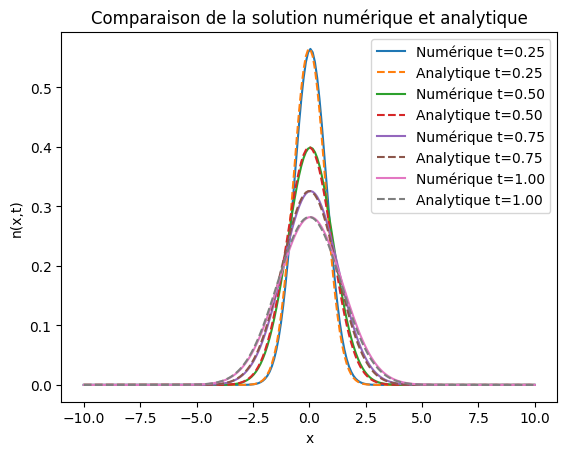

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# Paramètres
L = 10  # Domaine spatial [-L, L]
Nx = 200  # Nombre de points d'espace
Dx = 2 * L / Nx  # Pas spatial
Tmax = 1.0  # Temps max de simulation
Nt = 1000  # Nombre de pas de temps
Dt = Tmax / Nt  # Pas temporel
D = 1  # Coefficient de diffusion
Q = 1  # Source initiale

# Stabilité CFL
alpha = D * Dt / Dx**2
if alpha > 0.5:
    print("Attention : condition CFL non respectée (alpha =", alpha, ")")

# Discrétisation spatiale
x = np.linspace(-L, L, Nx)

# Condition initiale : Dirac delta approximée par une gaussienne fine
n = np.zeros(Nx)
n[Nx//2] = Q / Dx  # Approximation de la Dirac avec conservation de la masse

# Stockage pour la solution analytique
def solution_analytique(x, t, D, Q):
    return (Q / np.sqrt(4 * np.pi * D * t)) * np.exp(-x**2 / (4 * D * t))

# Boucle temporelle
for k in range(Nt):
    # Schéma explicite en différences finies
    n_new = n.copy()
    n_new[1:-1] = n[1:-1] + alpha * (n[2:] - 2 * n[1:-1] + n[:-2])
    n = n_new

    # Affichage tous les certains intervalles
    if (k+1) % (Nt // 4) == 0:
        plt.plot(x, n, label=f"Numérique t={k * Dt:.2f}")
        plt.plot(x, solution_analytique(x, k * Dt, D, Q), '--', label=f"Analytique t={k * Dt:.2f}")

# Affichage final
plt.xlabel("x")
plt.ylabel("n(x,t)")
plt.title("Comparaison de la solution numérique et analytique")
plt.legend()
plt.show()


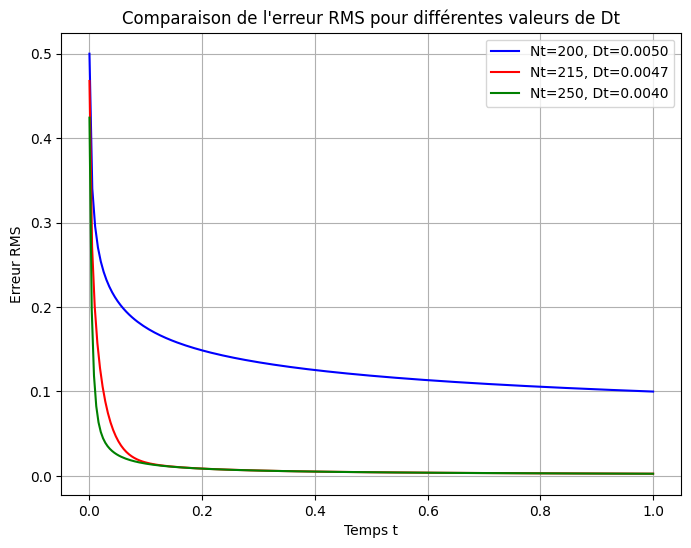

In [21]:
# Différentes valeurs de Nt pour tester différents pas de temps
Nt_values = [200, 215, 250]  # Différents nombres de pas de temps
couleurs = ['b', 'r', 'g']  # Couleurs pour chaque courbe

plt.figure(figsize=(8, 6))

for i, Nt in enumerate(Nt_values):
    Dt = Tmax / Nt  # Pas temporel
    alpha = D * Dt / Dx**2  # Vérification de la stabilité CFL

    if alpha > 0.5:
        print(f"Attention : CFL non respectée pour Nt={Nt} (alpha={alpha:.2f})")

    # Stockage de l'erreur RMS
    erreur_RMS = np.zeros(Nt)

    # Réinitialisation de la condition initiale
    n = np.zeros(Nx)
    n[Nx//2] = Q / Dx  

    for k in range(Nt):
        # Schéma explicite en différences finies
        n_new = n.copy()
        n_new[1:-1] = n[1:-1] + alpha * (n[2:] - 2 * n[1:-1] + n[:-2])
        n = n_new

        # Calcul de l'erreur RMS
        erreur_RMS[k] = np.sqrt(np.mean((n - solution_analytique(x, k * Dt, D, Q)) ** 2))

    # Tracer la courbe d'erreur RMS pour cette valeur de Nt
    plt.plot(np.linspace(0, Tmax, Nt), erreur_RMS, couleurs[i], label=f"Nt={Nt}, Dt={Dt:.4f}")

# Affichage
plt.xlabel("Temps t")
plt.ylabel("Erreur RMS")
plt.title("Comparaison de l'erreur RMS pour différentes valeurs de Dt")
plt.legend()
plt.grid()
plt.show()



# Vérification Numérique de la Largeur à Mi-Hauteur

Dans ce projet, nous allons simuler l'évolution de la distribution $n(x,t)$ d'une particule sous diffusion. Plutôt que de calculer l'écart-type de la distribution, nous allons mesurer la **largeur à mi-hauteur** de la distribution à chaque instant $t$. Cette méthode consiste à déterminer la largeur de la distribution à l'endroit où la valeur de $n(x,t)$ est égale à la moitié de sa valeur maximale.

## 1. Théorie de la Diffusion

La solution analytique de l'équation de diffusion 1D avec une source initiale de Dirac delta est donnée par :

$$
n(x,t) = \frac{Q}{\sqrt{4 \pi D t}} \exp\left( - \frac{x^2}{4 D t} \right)
$$

Où :
- $Q$ est la masse initiale de la source,
- $D$ est le coefficient de diffusion,
- $t$ est le temps.

La **largeur de la distribution** augmente avec le temps. Théoriquement, la largeur de la distribution à mi-hauteur évolue comme :

$$
\sigma(t) \sim \sqrt{2 D t}
$$

Cependant, pour une diffusion en une dimension, la largeur à mi-hauteur est liée à l'écart-type par un facteur constant. Cette relation théorique est donnée par :

$$
\text{Largeur à mi-hauteur} \sim 2 \sqrt{2 \ln(2)} \sigma(t)
$$

## 2. Simulation Numérique

Nous allons résoudre l'équation de diffusion numériquement en utilisant le schéma explicite en différences finies. Voici les étapes de la simulation :

1. **Discrétisation** : Le domaine spatial et temporel est discrétisé. Nous utilisons un pas spatial $Dx$ et un pas temporel $Dt$ pour simuler l'évolution de la distribution $n(x,t)$.

2. **Condition initiale** : La condition initiale est une approximation de la Dirac delta (gaussienne fine centrée en $x = 0$).

3. **Schéma explicite** : À chaque pas de temps, nous mettons à jour la distribution $n(x,t)$ en utilisant un schéma de différences finies.

4. **Largeur à mi-hauteur** : À chaque instant $t$, nous calculons la largeur à mi-hauteur de la distribution en trouvant les points où $n(x,t)$ est égal à la moitié de sa valeur maximale.

5. **Comparaison avec la théorie** : Nous comparons la largeur à mi-hauteur obtenue numériquement avec la largeur théorique qui suit la relation $2\sqrt{2 \ln(2)} \sigma(t)$.

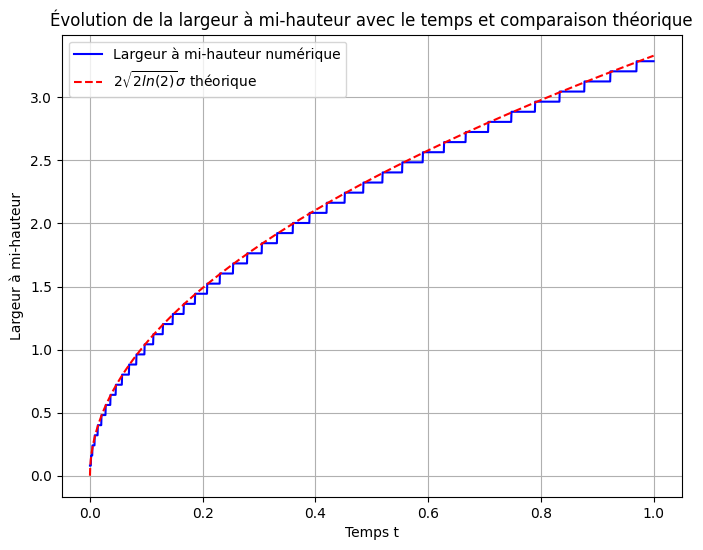

In [22]:
# Paramètres
L = 10  # Domaine spatial [-L, L]
Nx = 500  # Nombre de points d'espace
Dx = 2 * L / Nx  # Pas spatial
Tmax = 1.0  # Temps max de simulation
Nt = 2000  # Nombre de pas de temps
Dt = Tmax / Nt  # Pas temporel
D = 1  # Coefficient de diffusion
Q = 1  # Source initiale

# Discrétisation spatiale
x = np.linspace(-L, L, Nx)

# Initialisation de la condition initiale : Dirac delta approximée par une gaussienne fine
n = np.zeros(Nx)    
n[Nx//2] = Q / Dx  # Approximation de la Dirac avec conservation de la masse

# Stockage de la largeur à mi-hauteur
largeur_mi_hauteur = np.zeros(Nt)
ecart_type = np.sqrt(2*D*np.linspace(0, Tmax, Nt))

# Boucle temporelle
for k in range(Nt):
    # Schéma explicite en différences finies
    n_new = n.copy()
    n_new[1:-1] = n[1:-1] + D * Dt / Dx**2 * (n[2:] - 2 * n[1:-1] + n[:-2])
    n = n_new

    # Trouver la valeur maximale de n(x,t)
    n_max = np.max(n)
    
    # Déterminer la valeur à mi-hauteur
    mi_hauteur = n_max / 2
    
    # Trouver les indices où la distribution atteint la mi-hauteur
    indices_mi_hauteur = np.where(n >= mi_hauteur)[0]
    
    # Largeur à mi-hauteur est la différence entre les deux extrêmes
    if len(indices_mi_hauteur) > 1:
        largeur_mi_hauteur[k] = x[indices_mi_hauteur[-1]] - x[indices_mi_hauteur[0]]
    else:
        largeur_mi_hauteur[k] = 0  # Si la distribution ne dépasse pas la mi-hauteur, largeur est 0


plt.figure(figsize=(8, 6))

# Tracer la largeur à mi-hauteur numérique
plt.plot(np.linspace(0, Tmax, Nt), largeur_mi_hauteur, label="Largeur à mi-hauteur numérique", color="b")

# Tracer la référence théorique sqrt(2Dt)
plt.plot(np.linspace(0, Tmax, Nt), ecart_type*2*np.sqrt(2*np.log(2)), label=r"$2\sqrt{2ln(2)} \sigma$ théorique", color="r", linestyle="--")

# Affichage
plt.xlabel("Temps t")
plt.ylabel("Largeur à mi-hauteur")
plt.title("Évolution de la largeur à mi-hauteur avec le temps et comparaison théorique")
plt.legend()
plt.grid()
plt.show()


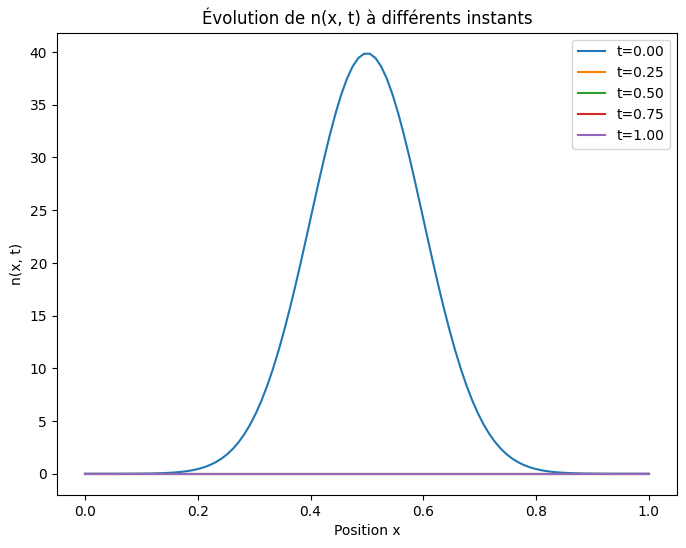

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from math import gamma

# Fonction analytique (à adapter selon le problème)
def n_analytique(x, t):
    r0 = (Q * gamma(1/m + 3/2)) / (np.sqrt(np.pi) * n0 * gamma(1/m +1))
    t0 = (m*r0**2) / (2*D0*(2+m))
    lam_t = (t/t0)**(1/(2+m))  # Exemple de lambda évoluant avec le temps
    mask = np.abs(x) < r0 * lam_t
    result = np.zeros_like(x)
    result[mask] = n0 * (1 / lam_t) * (1 - (x[mask] / (r0 * lam_t))**2) ** (1/m)
    return result


def solve_pde(Nx, Nt, L, T, D0, n0, m, Q):
    dx = L / Nx  # Discrétisation en espace
    dt = T / Nt  # Discrétisation en temps
    
    x = np.linspace(-L/2, L/2, Nx)
    sigma = L / 10  # Écart-type de la gaussienne
    n = np.zeros((Nt, Nx))  # Solution numérique initialisée à zéro
    n[0, :] = Q * np.exp(-x**2 / (2 * sigma**2)) / (sigma * np.sqrt(2 * np.pi))  # Condition initiale : gaussienne centrée
    
    for t in range(1, Nt - 1):
        dn_dx = np.zeros(Nx)
        dn2_dx2 = np.zeros(Nx)

        for i in range(1, Nx - 1):
            dn_dx[i] = n[t, i] ** (m - 1) * ((n[t, i+1] - n[t, i-1]) / (2*dt))**2
            dn2_dx2[i] = n[t, i] ** m * (n[t, i+1] - 2 * n[t, i] + n[t, i-1]) / dt**2
        
        for i in range(1, Nx - 1):
            n[t+1, i] = n[t, i] + 2*dt*(D0 / (n0 ** m)) * (dn_dx[i] + dn2_dx2[i])
    
    return n

# Paramètres
Nx, Nt = 100, 500  # Nombre de points en espace et temps
L, T = 1.0, 1.0  # Domaine spatial et temporel
D0, n0, m, Q = 1.0, 1.0, 2, 10.0  # Paramètres physiques

# Résolution numérique
n_solution = solve_pde(Nx, Nt, L, T, D0, n0, m, Q)

# Affichage de la solution à différents instants
times = [0, Nt//4, Nt//2, 3*Nt//4, Nt-1]
x = np.linspace(0, L, Nx)
plt.figure(figsize=(8, 6))
for t in times:
    plt.plot(x, n_solution[t, :], label=f't={t*T/Nt:.2f}')
plt.xlabel("Position x")
plt.ylabel("n(x, t)")
plt.legend()
plt.title("Évolution de n(x, t) à différents instants")
plt.show()
